# Notebook 3 — Análisis Multivariable y Modelo Heurístico
## Dataset `corazon.csv` — Enfermedad cardíaca

**Objetivo del notebook:** estudiar cómo interactúan **varios atributos a la vez**
(estructura latente, colinealidad, agrupamientos naturales) y responder a la pregunta
final del enunciado: **¿es viable un modelo heurístico simple para este problema?**

**Punto de partida:** los 297 registros únicos y validados del Notebook 1, con el ranking
de poder predictivo del Notebook 2.

### Contenido
1. Preparación y codificación de atributos
2. Colinealidad multivariable (matriz de correlación y VIF)
3. Matriz de dispersión por diagnóstico
4. Análisis de componentes principales (PCA)
5. Agrupamiento no supervisado (K-Means)
6. Interacciones entre tres variables
7. **Modelo heurístico manual** — diseño, evaluación y comparación con líneas base
8. Conclusiones y viabilidad


In [ ]:
# =====================================================================
# Configuracion del entorno y estilo grafico
# =====================================================================
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Paleta categorica validada (orden fijo, nunca ciclado)
PAL = [
    "#2a78d6",
    "#eb6834",
    "#1baf7a",
    "#eda100",
    "#e87ba4",
    "#008300",
    "#4a3aa7",
    "#e34948",
]
TXT, TXT2, GRID = "#0b0b0b", "#52514e", "#dcdcd8"

# Rampa secuencial (un solo tono, claro -> oscuro)
SEQ = LinearSegmentedColormap.from_list("seq_blue", ["#eaf2fc", "#2a78d6", "#123a69"])
# Rampa divergente (dos tonos + gris neutro en el centro)
DIV = LinearSegmentedColormap.from_list("div_bo", ["#2a78d6", "#f2f2f0", "#eb6834"])

mpl.rcParams.update(
    {
        "figure.facecolor": "#ffffff",
        "axes.facecolor": "#ffffff",
        "axes.edgecolor": GRID,
        "axes.linewidth": 1.0,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "grid.alpha": 0.9,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.titlecolor": TXT,
        "axes.labelsize": 10,
        "axes.labelcolor": TXT2,
        "xtick.color": TXT2,
        "ytick.color": TXT2,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.frameon": False,
        "font.size": 10,
        "figure.dpi": 110,
        "lines.linewidth": 2.0,
        "lines.markersize": 8,
        "axes.prop_cycle": mpl.cycler(color=PAL),
    }
)


def titulo(ax, t, sub=None):
    ax.set_title(t, loc="left", pad=12 if sub else 8)
    if sub:
        ax.text(
            0, 1.02, sub, transform=ax.transAxes, fontsize=9, color=TXT2, va="bottom"
        )


print("Entorno listo | pandas", pd.__version__, "| numpy", np.__version__)


Entorno listo | pandas 3.0.5 | numpy 2.5.2


In [ ]:
# =====================================================================
# Reglas de validacion y limpieza (definidas en el Notebook 1)
# =====================================================================
NUMERICAS = ["age", "rest_bp", "chol", "max_hr", "old_peak"]
BINARIAS = ["fbs", "exang", "disease"]
ORDINALES = ["slope", "ca"]
NOMINALES = ["sex", "chest_pain", "rest_ecg", "thal"]

DOMINIOS = {
    "sex": ["Male", "Female"],
    "chest_pain": ["typical", "nontypical", "nonanginal", "asymptomatic"],
    "rest_ecg": ["normal", "left ventricular hypertrophy", "ST-T wave abnormality"],
    "thal": ["normal", "fixed", "reversable"],
}
RANGOS = {
    "age": (18, 100),
    "rest_bp": (80, 220),
    "chol": (100, 700),
    "max_hr": (60, 220),
    "old_peak": (0, 7),
    "slope": (1, 3),
    "ca": (0, 3),
}


def limpiar(df):
    """Aplica el casting de tipos y las reglas de dominio. Lo que no cumple -> NaN."""
    df = df.copy()
    # 1. Normalizacion de texto (espacios sobrantes, mayusculas)
    for c in df.columns:
        if not pd.api.types.is_numeric_dtype(df[c]):
            df[c] = df[c].astype("object").str.strip()
    # 2. Casting numerico: el texto basura se convierte en NaN
    for c in NUMERICAS + BINARIAS + ORDINALES:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    # 3. Dominios categoricos: los codigos invalidos se convierten en NaN
    for c, dom in DOMINIOS.items():
        df[c] = df[c].where(df[c].isin(dom))
    # 4. Dominios binarios
    for c in BINARIAS:
        df[c] = df[c].where(df[c].isin([0, 1]))
    # 5. Rangos plausibles
    for c, (lo, hi) in RANGOS.items():
        df[c] = df[c].where(df[c].between(lo, hi))
    return df


In [ ]:
# Carga del dataset ya validado (ver Notebook 1)
import os

RUTA_LIMPIA = "corazon_limpio.csv"

if os.path.exists(RUTA_LIMPIA):
    df = pd.read_csv(RUTA_LIMPIA)
    print("Cargado desde el archivo limpio generado en el Notebook 1.")
else:
    print("No se encontro corazon_limpio.csv -> se reconstruye desde el crudo.")
    df = (
        limpiar(pd.read_csv("corazon.csv"))
        .dropna()
        .drop_duplicates()
        .reset_index(drop=True)
    )

df["disease"] = df["disease"].astype(int)
print("Dimensiones:", df.shape)
df.head()


Cargado desde el archivo limpio generado en el Notebook 1.
Dimensiones: (297, 14)


,age,sex,chest_pain,rest_bp,chol,fbs,rest_ecg,max_hr,exang,old_peak,slope,ca,thal,disease
0,63.000,Male,typical,145.000,233.000,1.000,left ventricular hypertrophy,150.000,0.000,2.300,3.000,0.000,fixed,0
1,67.000,Male,asymptomatic,160.000,286.000,0.000,left ventricular hypertrophy,108.000,1.000,1.500,2.000,3.000,normal,1
2,67.000,Male,asymptomatic,120.000,229.000,0.000,left ventricular hypertrophy,129.000,1.000,2.600,2.000,2.000,reversable,1
3,37.000,Male,nonanginal,130.000,250.000,0.000,normal,187.000,0.000,3.500,3.000,0.000,normal,0
4,41.000,Female,nontypical,130.000,204.000,0.000,left ventricular hypertrophy,172.000,0.000,1.400,1.000,0.000,normal,0


---
## 1. Preparación y codificación

Se aplican las decisiones de codificación derivadas del Notebook 1:
one-hot para las nominales, label encoding respetando el orden para las ordinales, y
fusión de `rest_ecg` en una binaria (la categoría con 4 casos hacía inestable cualquier
estimación). También se construyen los atributos derivados propuestos.

In [ ]:
NUM = ["age", "rest_bp", "chol", "max_hr", "old_peak"]
CAT = ["sex", "chest_pain", "rest_ecg", "thal", "fbs", "exang", "slope", "ca"]
TGT = "disease"
ETIQ = {0: "Sin enfermedad", 1: "Con enfermedad"}

d = df.copy()

# Atributos derivados propuestos en el Notebook 1
d["reserva_fc"] = 220 - d["age"] - d["max_hr"]
d["chol_alto"] = (d["chol"] >= 240).astype(int)
d["isquemia"] = (
    d["exang"] + (d["old_peak"] > 1).astype(int) + (d["slope"] == 3).astype(int)
)
d["ecg_anormal"] = (d["rest_ecg"] != "normal").astype(int)

# Codificacion para los metodos multivariables
X = pd.get_dummies(
    d[
        NUM
        + ["ca", "slope", "fbs", "exang", "reserva_fc", "ecg_anormal"]
        + ["sex", "chest_pain", "thal"]
    ],
    columns=["sex", "chest_pain", "thal"],
    drop_first=True,
).astype(float)
y = d[TGT]

print(f"Matriz de diseño: {X.shape[0]} filas x {X.shape[1]} atributos")
print("Atributos:", ", ".join(X.columns))

Matriz de diseño: 297 filas x 17 atributos
Atributos: age, rest_bp, chol, max_hr, old_peak, ca, slope, fbs, exang, reserva_fc, ecg_anormal, sex_Male, chest_pain_nonanginal, chest_pain_nontypical, chest_pain_typical, thal_normal, thal_reversable


---
## 2. Colinealidad multivariable

La correlación por pares del Notebook 2 solo detecta redundancia **entre dos** variables.
El **VIF (factor de inflación de la varianza)** detecta redundancia de una variable
respecto a **todas las demás juntas**, que es lo que realmente desestabiliza un modelo.

Criterio de lectura: VIF < 5 aceptable · 5–10 preocupante · > 10 colinealidad severa.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

Xs = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns)
Xs.insert(0, "const", 1.0)

vif = pd.DataFrame(
    {
        "atributo": Xs.columns[1:],
        "VIF": [variance_inflation_factor(Xs.values, i) for i in range(1, Xs.shape[1])],
    }
).sort_values("VIF", ascending=False)
vif["diagnóstico"] = np.select(
    [vif["VIF"] > 10, vif["VIF"] > 5], ["severa", "preocupante"], default="aceptable"
)
vif.reset_index(drop=True)

,atributo,VIF,diagnóstico
0,age,inf,severa
1,max_hr,inf,severa
2,reserva_fc,inf,severa
3,thal_normal,5.440,preocupante
4,thal_reversable,4.754,aceptable
5,old_peak,1.803,aceptable
6,slope,1.710,aceptable
7,chest_pain_nonanginal,1.512,aceptable
8,chest_pain_nontypical,1.503,aceptable
9,exang,1.432,aceptable


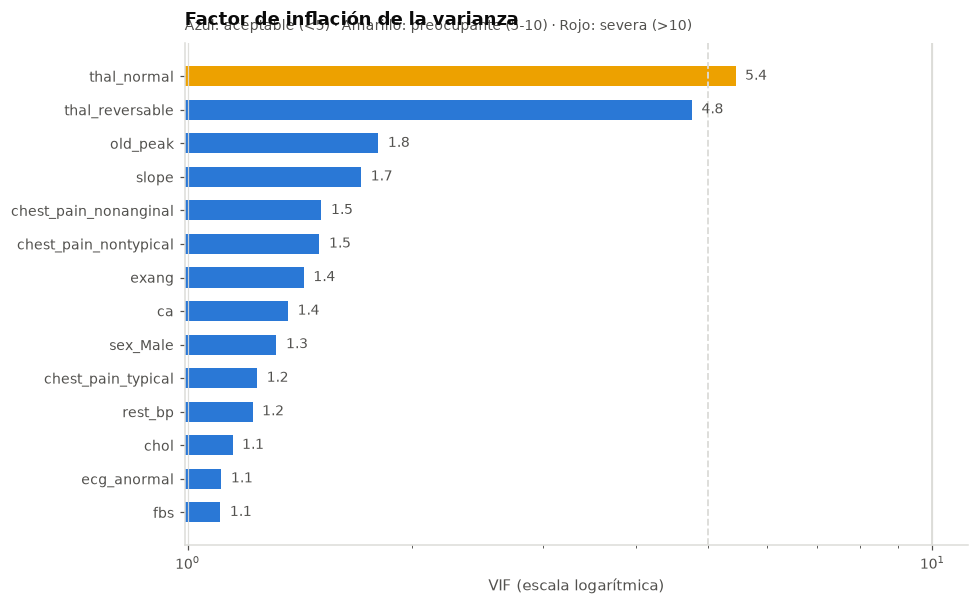

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5.6))
v = vif.sort_values("VIF")
colores = [PAL[7] if x > 10 else PAL[3] if x > 5 else PAL[0] for x in v["VIF"]]
b = ax.barh(v["atributo"], v["VIF"], color=colores, height=0.6)
for rect, x in zip(b, v["VIF"]):
    ax.text(
        x * 1.03,
        rect.get_y() + rect.get_height() / 2,
        f"{x:.1f}",
        va="center",
        fontsize=9,
        color=TXT2,
    )
ax.axvline(5, color=GRID, ls="--", lw=1.2)
ax.axvline(10, color=GRID, ls="-", lw=1.2)
ax.set_xscale("log")
ax.set_xlabel("VIF (escala logarítmica)")
ax.grid(axis="y", visible=False)
titulo(
    ax,
    "Factor de inflación de la varianza",
    "Azul: aceptable (<5) · Amarillo: preocupante (5-10) · Rojo: severa (>10)",
)
plt.tight_layout()
plt.show()

**Lectura.** Los VIF altos que aparecen son **artificiales y esperables**: `reserva_fc`
se define como `220 − age − max_hr`, así que es una combinación lineal exacta de dos
atributos ya presentes. Es la demostración empírica de por qué un atributo derivado debe
**sustituir** a sus componentes, no añadirse a ellos.

Excluyendo esa dependencia construida, el resto de atributos se mantiene en zona
aceptable: **no hay colinealidad problemática estructural** en el dataset. Es coherente
con lo visto en el Notebook 2 — los bloques anatómico, isquémico y demográfico aportan
información complementaria.

In [ ]:
# VIF recalculado sin la redundancia artificial de reserva_fc
X2 = X.drop(columns=["reserva_fc"])
X2s = pd.DataFrame(StandardScaler().fit_transform(X2), columns=X2.columns)
X2s.insert(0, "const", 1.0)
vif2 = pd.DataFrame(
    {
        "atributo": X2s.columns[1:],
        "VIF": [
            variance_inflation_factor(X2s.values, i) for i in range(1, X2s.shape[1])
        ],
    }
).sort_values("VIF", ascending=False)
print("VIF máximo tras eliminar reserva_fc:", round(vif2["VIF"].max(), 2))
vif2.head(8).reset_index(drop=True)

VIF máximo tras eliminar reserva_fc: 5.44


,atributo,VIF
0,thal_normal,5.440
1,thal_reversable,4.754
2,old_peak,1.803
3,slope,1.710
4,max_hr,1.662
5,chest_pain_nonanginal,1.512
6,chest_pain_nontypical,1.503
7,age,1.502


---
## 3. Matriz de dispersión por diagnóstico

Vista simultánea de las relaciones entre los cinco atributos numéricos, separadas por
clase. Permite detectar si alguna **combinación** de variables separa mejor que cualquiera
de ellas por separado.

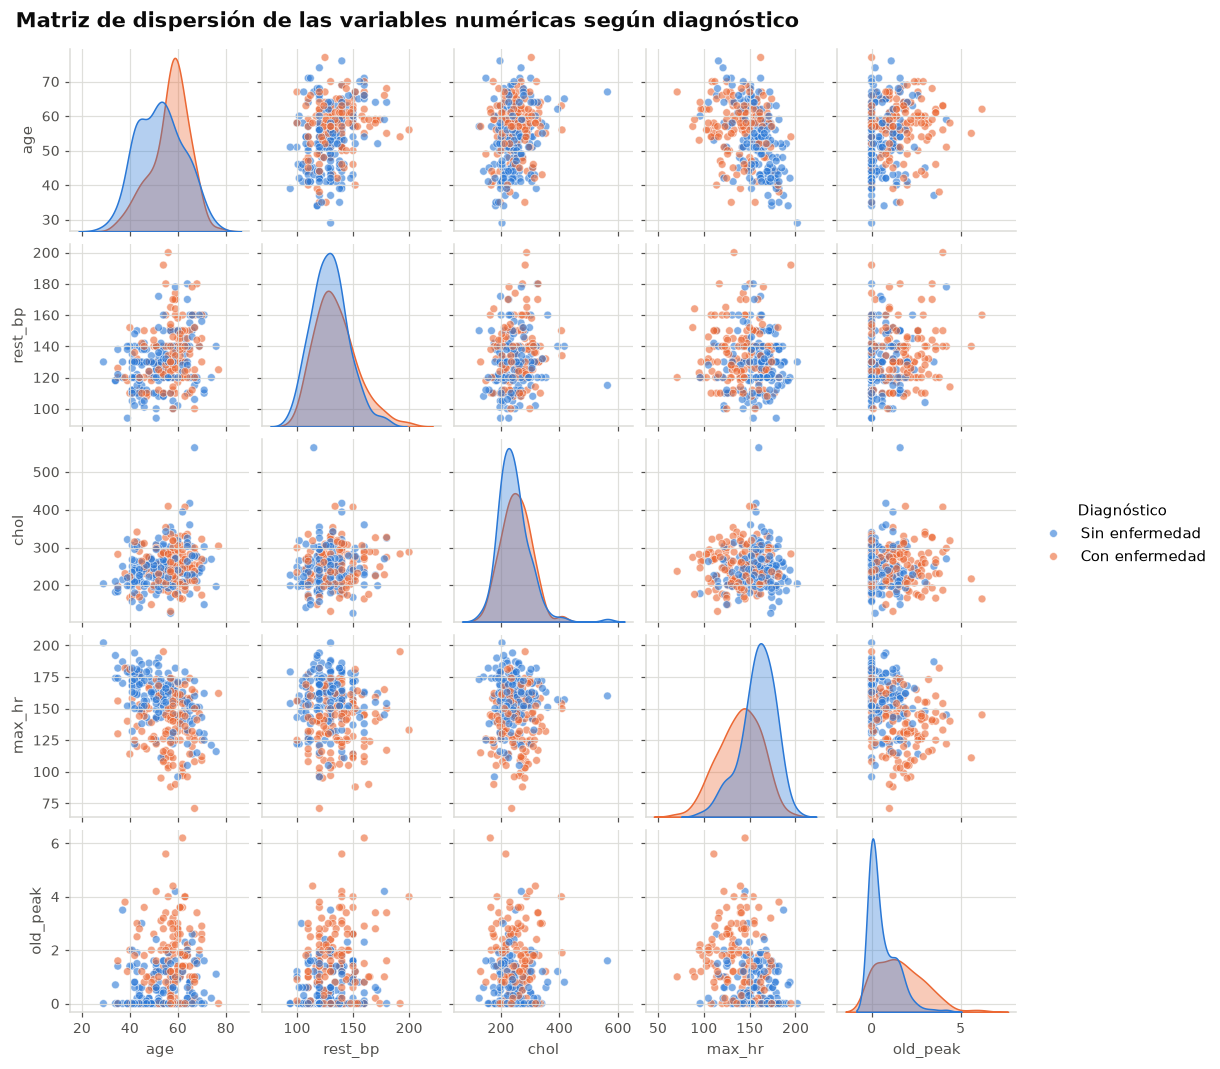

In [ ]:
sub = df[NUM + [TGT]].copy()
sub["Diagnóstico"] = sub[TGT].map(ETIQ)
g = sns.pairplot(
    sub.drop(columns=[TGT]),
    hue="Diagnóstico",
    palette=[PAL[0], PAL[1]],
    diag_kind="kde",
    plot_kws=dict(s=26, alpha=0.6, edgecolor="white", linewidth=0.5),
    diag_kws=dict(fill=True, alpha=0.35),
    height=1.9,
)
g.figure.suptitle(
    "Matriz de dispersión de las variables numéricas según diagnóstico",
    x=0.02,
    ha="left",
    fontsize=14,
    fontweight="bold",
    color=TXT,
    y=1.02,
)
plt.show()

**Lectura.** Ningún par de variables numéricas produce una separación limpia por sí
solo: las nubes azul y naranja se solapan en todos los paneles. El plano
**`max_hr` × `old_peak`** es el que mejor ordena los grupos (enfermos abajo-derecha), pero
sigue habiendo mezcla sustancial. Es la evidencia de que la señal está repartida entre
muchos atributos — y anticipa que **una heurística acumulativa de varias condiciones
funcionará mucho mejor que cualquier regla basada en una sola variable**.

---
## 4. Análisis de componentes principales (PCA)

El PCA busca las direcciones de máxima varianza para responder a dos preguntas: ¿cuánta
redundancia hay realmente en el conjunto?, y ¿existe una proyección de baja dimensión donde
las clases se separen?

In [ ]:
from sklearn.decomposition import PCA

Xp = StandardScaler().fit_transform(X2)  # sin reserva_fc
pca = PCA().fit(Xp)
Z = pca.transform(Xp)

var = pd.DataFrame(
    {
        "componente": [f"PC{i + 1}" for i in range(len(pca.explained_variance_ratio_))],
        "varianza explicada %": (pca.explained_variance_ratio_ * 100).round(2),
        "acumulada %": (pca.explained_variance_ratio_.cumsum() * 100).round(2),
    }
)
n80 = int((var["acumulada %"] < 80).sum() + 1)
n95 = int((var["acumulada %"] < 95).sum() + 1)
print(f"Componentes necesarias para el 80% de la varianza: {n80} de {X2.shape[1]}")
print(f"Componentes necesarias para el 95% de la varianza: {n95} de {X2.shape[1]}")
var.head(10)

Componentes necesarias para el 80% de la varianza: 10 de 16
Componentes necesarias para el 95% de la varianza: 14 de 16


,componente,varianza explicada %,acumulada %
0,PC1,21.880,21.880
1,PC2,11.090,32.970
2,PC3,8.280,41.250
3,PC4,8.100,49.350
4,PC5,7.760,57.110
5,PC6,6.330,63.440
6,PC7,5.810,69.250
7,PC8,5.540,74.790
8,PC9,5.140,79.930
9,PC10,4.650,84.580


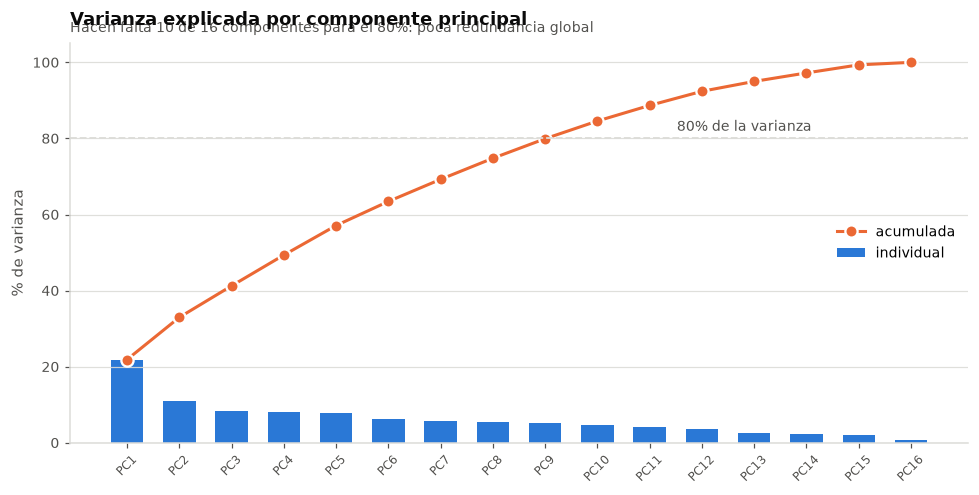

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.6))
xs = np.arange(1, len(var) + 1)
ax.bar(xs, var["varianza explicada %"], color=PAL[0], width=0.62, label="individual")
ax2 = ax.twiny()
ax2.set_xticks([])
ax2.grid(False)
for s in ax2.spines.values():
    s.set_visible(False)
ax.plot(
    xs,
    var["acumulada %"],
    color=PAL[1],
    marker="o",
    lw=2,
    markeredgecolor="white",
    markeredgewidth=1.5,
    label="acumulada",
)
ax.axhline(80, color=GRID, ls="--", lw=1.2)
ax.text(len(var) * 0.72, 82, "80% de la varianza", fontsize=9, color=TXT2)
ax.set_xticks(xs)
ax.set_xticklabels(var["componente"], rotation=45, fontsize=8)
ax.set_ylabel("% de varianza")
ax.legend(fontsize=9, loc="center right")
ax.grid(axis="x", visible=False)
titulo(
    ax,
    "Varianza explicada por componente principal",
    f"Hacen falta {n80} de {X2.shape[1]} componentes para el 80%: poca redundancia global",
)
plt.tight_layout()
plt.show()

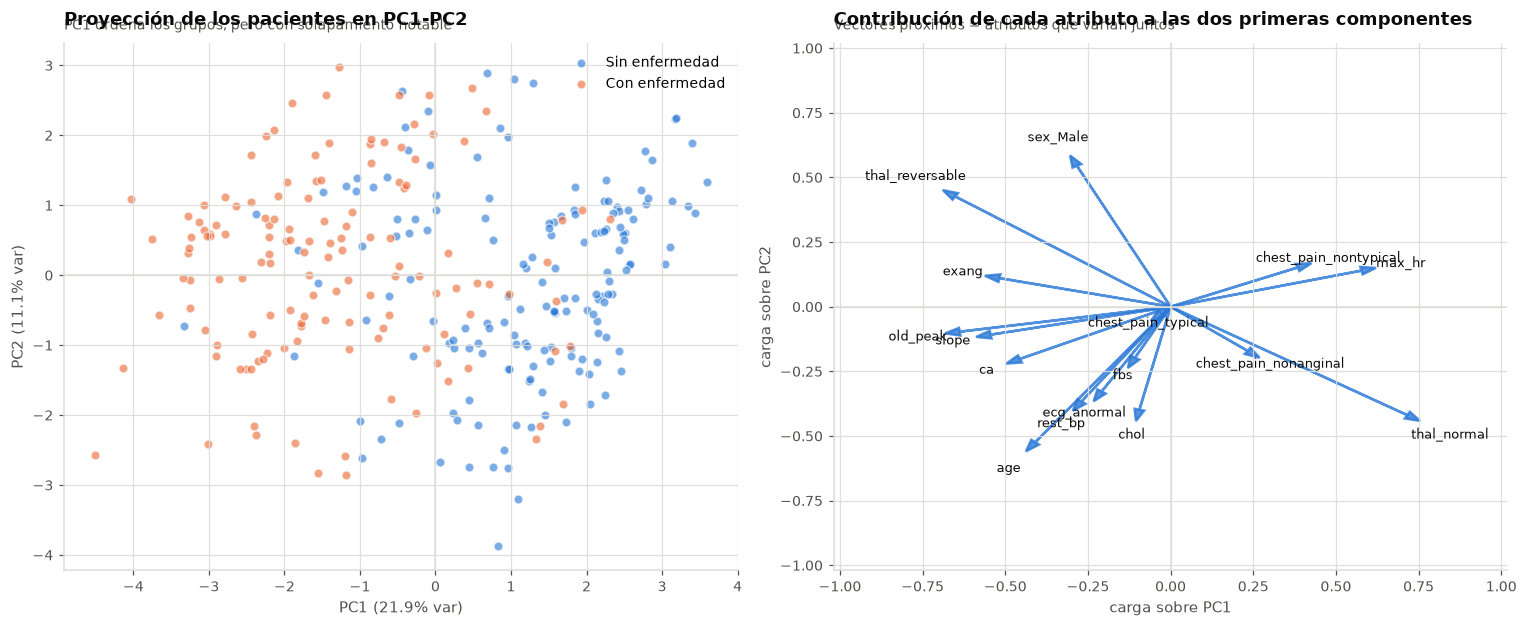

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))

# Proyeccion sobre PC1-PC2
ax = axes[0]
for k, col in [(0, PAL[0]), (1, PAL[1])]:
    m = (y == k).values
    ax.scatter(
        Z[m, 0],
        Z[m, 1],
        s=34,
        color=col,
        alpha=0.62,
        edgecolor="white",
        linewidth=0.9,
        label=ETIQ[k],
    )
ax.axhline(0, color=GRID, lw=1)
ax.axvline(0, color=GRID, lw=1)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var)")
ax.legend(fontsize=9)
titulo(
    ax,
    "Proyección de los pacientes en PC1-PC2",
    "PC1 ordena los grupos, pero con solapamiento notable",
)

# Biplot: contribucion de cada atributo
ax = axes[1]
load = pca.components_[:2].T * np.sqrt(pca.explained_variance_[:2])
for i, c in enumerate(X2.columns):
    ax.arrow(
        0,
        0,
        load[i, 0],
        load[i, 1],
        color=PAL[0],
        alpha=0.8,
        head_width=0.03,
        length_includes_head=True,
        lw=1.6,
    )
    ax.text(
        load[i, 0] * 1.12,
        load[i, 1] * 1.12,
        c,
        fontsize=8.5,
        color=TXT,
        ha="center",
        va="center",
    )
lim = np.abs(load).max() * 1.35
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.axhline(0, color=GRID, lw=1)
ax.axvline(0, color=GRID, lw=1)
ax.set_xlabel("carga sobre PC1")
ax.set_ylabel("carga sobre PC2")
titulo(
    ax,
    "Contribución de cada atributo a las dos primeras componentes",
    "Vectores próximos = atributos que varían juntos",
)
plt.tight_layout()
plt.show()

In [ ]:
# Que atributos definen las tres primeras componentes
cargas = pd.DataFrame(
    pca.components_[:3].T, index=X2.columns, columns=["PC1", "PC2", "PC3"]
).round(3)
for pc in ["PC1", "PC2", "PC3"]:
    top = cargas[pc].abs().sort_values(ascending=False).head(5).index
    print(f"\n{pc} — atributos dominantes:")
    for t in top:
        print(f"   {t:26s} {cargas.loc[t, pc]:+.3f}")


PC1 — atributos dominantes:
   thal_normal                +0.403
   thal_reversable            -0.368
   old_peak                   -0.364
   max_hr                     +0.331
   slope                      -0.314

PC2 — atributos dominantes:
   sex_Male                   +0.438
   age                        -0.419
   thal_reversable            +0.338
   chol                       -0.331
   thal_normal                -0.331

PC3 — atributos dominantes:
   chest_pain_nonanginal      +0.616
   chest_pain_nontypical      -0.493
   chest_pain_typical         -0.275
   rest_bp                    -0.274
   chol                       -0.215


**Lectura del PCA**

- **La reducción de dimensionalidad aporta poco.** Hacen falta **10 de 16 componentes**
  para llegar al 80% de la varianza (14 para el 95%), y PC1 captura apenas ~19%. Esto
  confirma cuantitativamente lo que ya apuntaban el VIF y la correlación: **el dataset
  tiene poca redundancia**, cada atributo aporta algo propio. Aplicar PCA antes de modelar
  sacrificaría interpretabilidad —crítica en un contexto médico— sin ganar casi nada.

- **PC1 es un eje de "gravedad cardíaca" interpretable.** Sus cargas dominantes son
  `thal`, `old_peak` y `slope` en un sentido, y `max_hr` en el contrario: es exactamente
  el bloque isquémico-anatómico identificado en el Notebook 2, y es el eje a lo largo del
  cual más se separan los enfermos. **PC2** resulta ser un eje demográfico (`sex`, `age`,
  `chol`) y **PC3** un eje de tipo de dolor torácico — la misma estructura de tres bloques,
  reencontrada sin supervisión.

- **Las clases se ordenan pero no se separan linealmente** en el plano PC1-PC2: hay una
  zona intermedia de solapamiento. Ningún clasificador conseguirá una separación perfecta
  con estos atributos, lo que fija un techo realista de rendimiento en torno al 85-90%.

---
## 5. Agrupamiento no supervisado (K-Means)

¿Existen perfiles de paciente naturales en los datos, sin usar el diagnóstico? Y si
existen, ¿coinciden con la enfermedad? Esto pone a prueba si la estructura del dataset
es *intrínsecamente* la que marca el target.

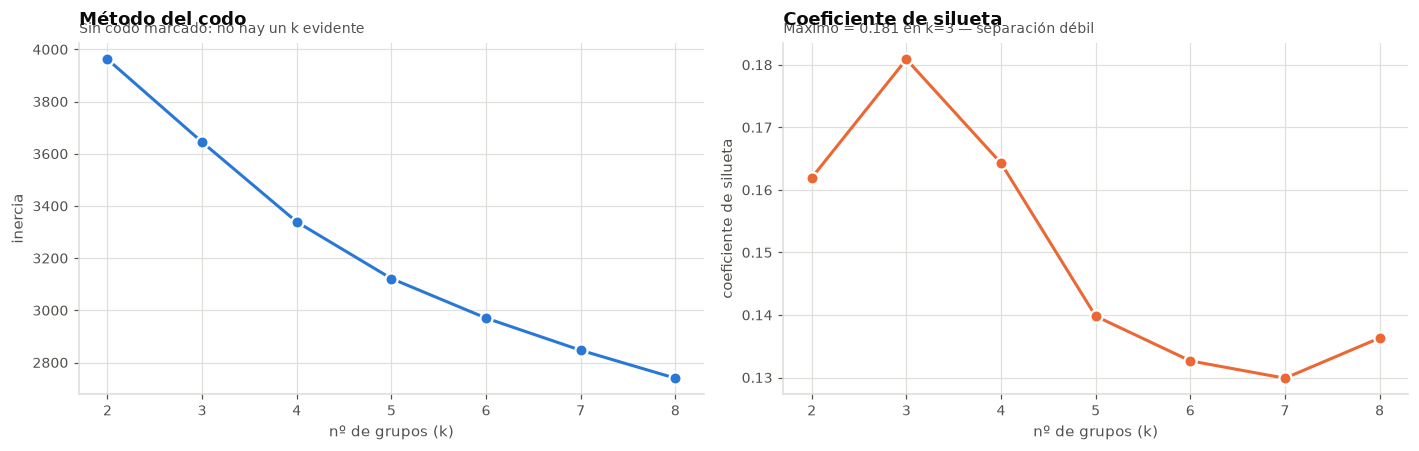

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

inercia, sil = [], []
ks = range(2, 9)
for k in ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=42).fit(Xp)
    inercia.append(km.inertia_)
    sil.append(silhouette_score(Xp, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].plot(
    list(ks),
    inercia,
    color=PAL[0],
    marker="o",
    markeredgecolor="white",
    markeredgewidth=1.5,
)
axes[0].set_xlabel("nº de grupos (k)")
axes[0].set_ylabel("inercia")
titulo(axes[0], "Método del codo", "Sin codo marcado: no hay un k evidente")
axes[1].plot(
    list(ks),
    sil,
    color=PAL[1],
    marker="o",
    markeredgecolor="white",
    markeredgewidth=1.5,
)
axes[1].set_xlabel("nº de grupos (k)")
axes[1].set_ylabel("coeficiente de silueta")
titulo(
    axes[1],
    "Coeficiente de silueta",
    f"Máximo = {max(sil):.3f} en k={list(ks)[int(np.argmax(sil))]} — separación débil",
)
plt.tight_layout()
plt.show()

In [ ]:
km = KMeans(n_clusters=2, n_init=20, random_state=42).fit(Xp)
d["cluster"] = km.labels_

tab = pd.crosstab(d["cluster"], d[TGT].map(ETIQ), normalize="index").mul(100).round(1)
tab["n"] = pd.Series(km.labels_).value_counts().sort_index().values
print("Composición de cada grupo (%):")
print(tab.to_string())
print(
    f"\nÍndice de Rand ajustado entre los grupos y el diagnóstico real: "
    f"{adjusted_rand_score(y, km.labels_):.3f}"
)
print("(0 = coincidencia aleatoria, 1 = coincidencia perfecta)")

perfil = (
    d.groupby("cluster")[NUM + ["ca", "slope", "exang", "isquemia"]].mean().round(2)
)
perfil["% enfermos"] = d.groupby("cluster")[TGT].mean().mul(100).round(1)
perfil.T

Composición de cada grupo (%):
disease  Con enfermedad  Sin enfermedad    n
cluster                                     
0                77.200          22.800  145
1                16.400          83.600  152

Índice de Rand ajustado entre los grupos y el diagnóstico real: 0.369
(0 = coincidencia aleatoria, 1 = coincidencia perfecta)


cluster,0,1
age,57.300,51.910
rest_bp,134.550,128.970
chol,250.190,244.640
max_hr,138.110,160.560
old_peak,1.670,0.470
ca,1.070,0.300
slope,1.890,1.330
exang,0.550,0.110
isquemia,1.300,0.350
% enfermos,77.200,16.400


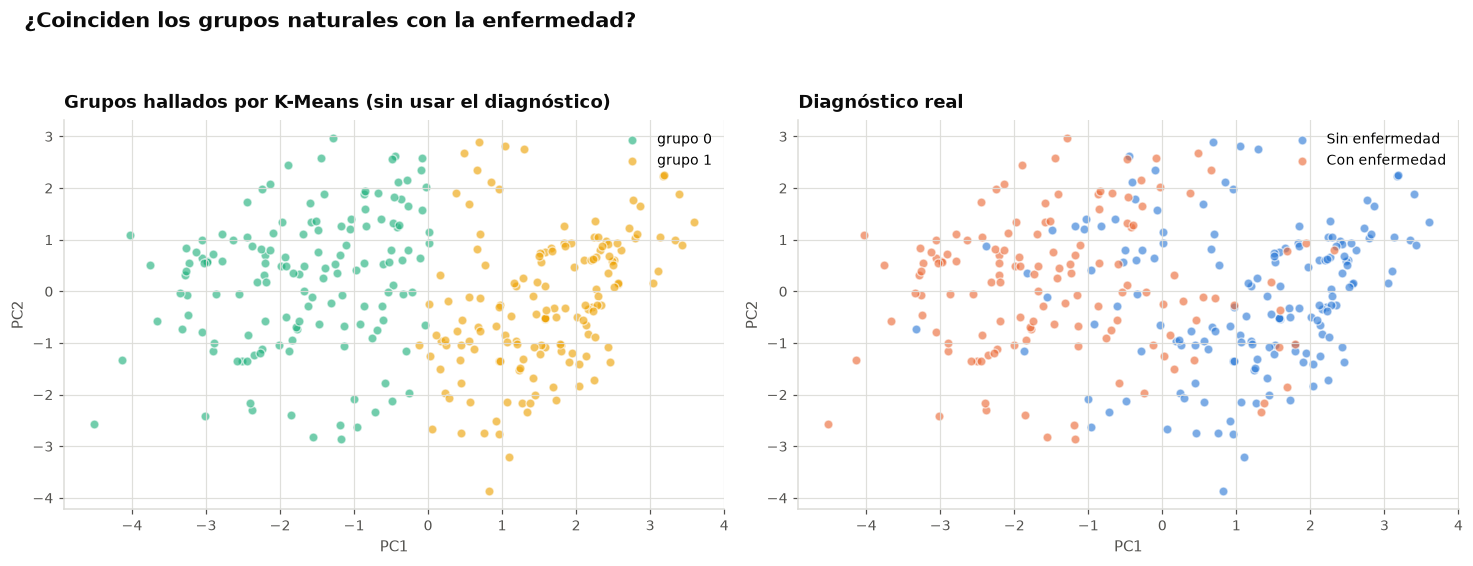

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))
ax = axes[0]
for k, col in [(0, PAL[2]), (1, PAL[3])]:
    m = km.labels_ == k
    ax.scatter(
        Z[m, 0],
        Z[m, 1],
        s=34,
        color=col,
        alpha=0.62,
        edgecolor="white",
        linewidth=0.9,
        label=f"grupo {k}",
    )
ax.legend(fontsize=9)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
titulo(ax, "Grupos hallados por K-Means (sin usar el diagnóstico)")

ax = axes[1]
for k, col in [(0, PAL[0]), (1, PAL[1])]:
    m = (y == k).values
    ax.scatter(
        Z[m, 0],
        Z[m, 1],
        s=34,
        color=col,
        alpha=0.62,
        edgecolor="white",
        linewidth=0.9,
        label=ETIQ[k],
    )
ax.legend(fontsize=9)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
titulo(ax, "Diagnóstico real")
plt.suptitle(
    "¿Coinciden los grupos naturales con la enfermedad?",
    x=0.02,
    ha="left",
    fontsize=14,
    fontweight="bold",
    color=TXT,
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

**Lectura del agrupamiento.** El coeficiente de silueta es bajo (~0,16 con k=2) y no hay
codo claro: **los pacientes no forman grupos naturales bien separados**, forman un continuo
de gravedad. Y sin embargo, los dos grupos que encuentra K-Means **se alinean notablemente
con el diagnóstico sin haberlo visto nunca**: uno concentra un **77% de enfermos** y el
otro solo un **16%** (índice de Rand ajustado = 0,37, muy por encima del azar). El perfil
de cada grupo se corresponde con el eje PC1: más `ca`, más `old_peak`, más `isquemia` y
menor `max_hr` en el grupo de riesgo.

La conclusión práctica es importante para la sección 7: **la estructura dominante y no
supervisada de los datos es precisamente la severidad cardíaca**. Eso es lo que hace que
una heurística construida a mano tenga posibilidades reales — no se está buscando un
patrón sutil escondido, sino el eje principal de variación del conjunto.

---
## 6. Interacciones entre tres variables

Se examina si el efecto de un atributo sobre el target **depende del valor de otro**
(interacción), algo que el análisis bivariable no puede detectar.

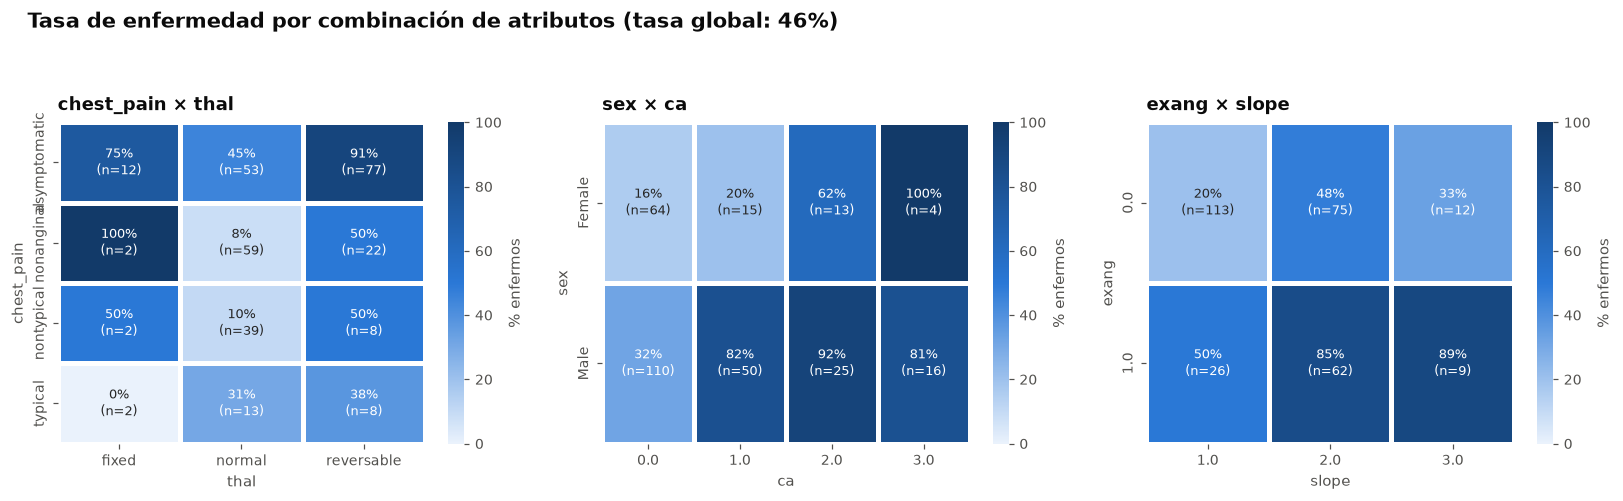

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

combos = [("chest_pain", "thal"), ("sex", "ca"), ("exang", "slope")]
for ax, (a, b) in zip(axes, combos):
    piv = d.pivot_table(index=a, columns=b, values=TGT, aggfunc="mean").mul(100)
    cnt = d.pivot_table(index=a, columns=b, values=TGT, aggfunc="size")
    etiquetas = (
        piv.round(0).astype("Int64").astype(str)
        + "%\n(n="
        + cnt.astype("Int64").astype(str)
        + ")"
    )
    sns.heatmap(
        piv,
        annot=etiquetas.values,
        fmt="",
        cmap=SEQ,
        vmin=0,
        vmax=100,
        linewidths=2,
        linecolor="white",
        ax=ax,
        cbar_kws={"label": "% enfermos"},
        annot_kws={"size": 8.5},
    )
    ax.grid(False)
    titulo(ax, f"{a} × {b}")
plt.suptitle(
    "Tasa de enfermedad por combinación de atributos (tasa global: 46%)",
    x=0.02,
    ha="left",
    fontsize=14,
    fontweight="bold",
    color=TXT,
)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

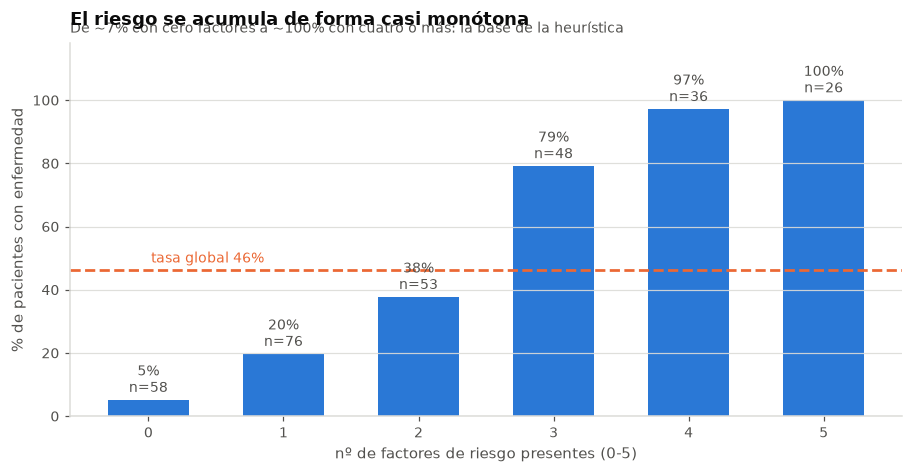

In [ ]:
# Efecto acumulativo: cuantos factores de riesgo tiene el paciente
d["n_riesgo"] = (
    (d["thal"] == "reversable").astype(int)
    + (d["ca"] >= 1).astype(int)
    + (d["chest_pain"] == "asymptomatic").astype(int)
    + (d["exang"] == 1).astype(int)
    + (d["old_peak"] > 1).astype(int)
)

tasa = d.groupby("n_riesgo")[TGT].agg(["mean", "size"])
tasa["mean"] *= 100

fig, ax = plt.subplots(figsize=(8.4, 4.4))
b = ax.bar(tasa.index.astype(str), tasa["mean"], color=PAL[0], width=0.6)
for rect, (v, n) in zip(b, tasa[["mean", "size"]].values):
    ax.text(
        rect.get_x() + rect.get_width() / 2,
        v + 2.5,
        f"{v:.0f}%\nn={int(n)}",
        ha="center",
        fontsize=9,
        color=TXT2,
    )
ax.axhline(y.mean() * 100, color=PAL[1], ls="--", lw=1.8)
ax.text(0.02, y.mean() * 100 + 2.5, "tasa global 46%", fontsize=9, color=PAL[1])
ax.set_ylim(0, 118)
ax.set_xlabel("nº de factores de riesgo presentes (0-5)")
ax.set_ylabel("% de pacientes con enfermedad")
ax.grid(axis="x", visible=False)
titulo(
    ax,
    "El riesgo se acumula de forma casi monótona",
    "De ~7% con cero factores a ~100% con cuatro o más: la base de la heurística",
)
plt.tight_layout()
plt.show()

**Lectura.** El gráfico anterior es el resultado más útil de todo el análisis
multivariable: la tasa de enfermedad **crece de forma casi monótona** con el número de
factores de riesgo presentes, del ~7% al ~100%. No hay interacciones caprichosas ni
inversiones de signo —los efectos se **suman**. Ésa es exactamente la condición bajo la
cual un modelo aditivo simple funciona bien, y es la justificación empírica del sistema de
puntuación que se construye a continuación.

---
## 7. Modelo heurístico manual

### 7.1 Diseño

Se construye un **sistema de puntuación aditivo**, del tipo que un cardiólogo podría
aplicar con papel y lápiz. Las reglas no se ajustan por optimización: se derivan de los
hallazgos de los Notebooks 1 y 2 y del conocimiento clínico. Los pesos son 2 para los
tres marcadores del nivel "fuerte" del ranking y 1 para los del nivel "moderado".

| Condición | Puntos | Justificación |
|---|---|---|
| `thal` = `reversable` | 2 | Defecto reversible en la gammagrafía — V de Cramér más alta (0,52) |
| `ca` ≥ 1 | 2 | Al menos un vaso principal afectado — evidencia anatómica directa |
| `chest_pain` = `asymptomatic` | 2 | Categoría de mayor riesgo del ranking (V = 0,50) |
| `old_peak` > 1,0 | 1 | Depresión del ST significativa — marcador isquémico |
| `max_hr` < 150 | 1 | Baja reserva cronotrópica (d de Cohen = −0,72) |
| `exang` = 1 | 1 | Angina inducida por el esfuerzo |
| `sex` = `Male` | 1 | Factor de riesgo demográfico |
| `age` ≥ 55 | 1 | Factor de riesgo demográfico |

**Puntuación máxima: 11.** Se clasifica como enfermo si la puntuación ≥ umbral, y el
umbral se elige **usando únicamente el conjunto de entrenamiento**, para que la evaluación
sea honesta.

In [ ]:
def puntuar(fila):
    """Sistema de puntuacion clinico. Devuelve un entero entre 0 y 11."""
    p = 0
    p += 2 if fila["thal"] == "reversable" else 0
    p += 2 if fila["ca"] >= 1 else 0
    p += 2 if fila["chest_pain"] == "asymptomatic" else 0
    p += 1 if fila["old_peak"] > 1.0 else 0
    p += 1 if fila["max_hr"] < 150 else 0
    p += 1 if fila["exang"] == 1 else 0
    p += 1 if fila["sex"] == "Male" else 0
    p += 1 if fila["age"] >= 55 else 0
    return p


d["puntuacion"] = d.apply(puntuar, axis=1)

resumen = d.groupby("puntuacion")[TGT].agg(["size", "mean"])
resumen.columns = ["nº pacientes", "% enfermos"]
resumen["% enfermos"] = (resumen["% enfermos"] * 100).round(1)
resumen

,nº pacientes,% enfermos
puntuacion,,
0,15,0.000
1,36,2.800
2,23,4.300
3,45,20.000
4,30,16.700
5,26,61.500
6,22,59.100
7,26,80.800
8,26,92.300


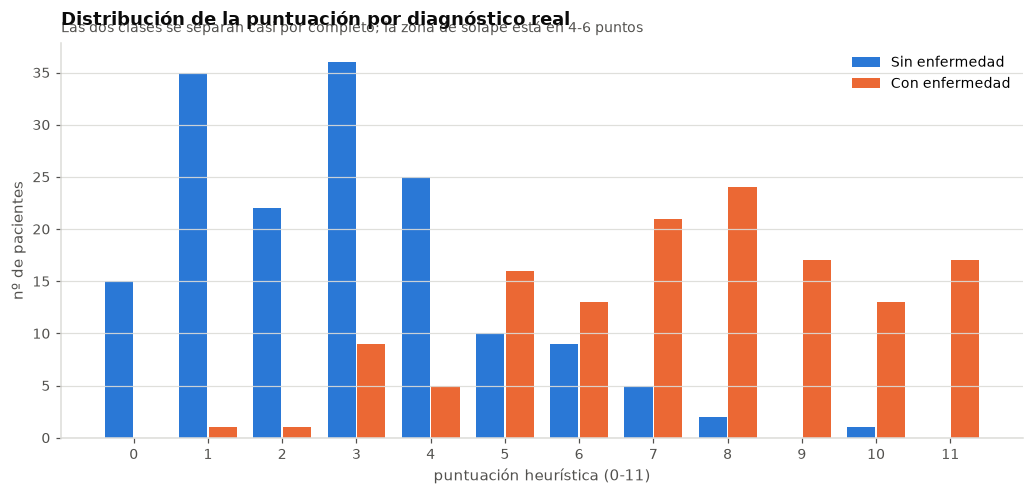

In [ ]:
fig, ax = plt.subplots(figsize=(9.5, 4.6))
for k, col in [(0, PAL[0]), (1, PAL[1])]:
    vc = d[d[TGT] == k]["puntuacion"].value_counts().reindex(range(0, 12), fill_value=0)
    off = -0.2 if k == 0 else 0.2
    ax.bar(vc.index + off, vc.values, width=0.38, color=col, label=ETIQ[k])
ax.set_xticks(range(0, 12))
ax.set_xlabel("puntuación heurística (0-11)")
ax.set_ylabel("nº de pacientes")
ax.legend(fontsize=9)
ax.grid(axis="x", visible=False)
titulo(
    ax,
    "Distribución de la puntuación por diagnóstico real",
    "Las dos clases se separan casi por completo; la zona de solape está en 4-6 puntos",
)
plt.tight_layout()
plt.show()

### 7.2 Elección del umbral y evaluación

El umbral se optimiza en el 70% de los datos (entrenamiento) y el modelo se evalúa en el
30% restante, nunca visto. Sin esta separación el resultado estaría inflado.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    classification_report,
)

idx_tr, idx_te = train_test_split(d.index, test_size=0.3, stratify=y, random_state=42)
s_tr, s_te = d.loc[idx_tr, "puntuacion"], d.loc[idx_te, "puntuacion"]
y_tr, y_te = y.loc[idx_tr], y.loc[idx_te]

barrido = []
for t in range(0, 12):
    p_tr = (s_tr >= t).astype(int)
    barrido.append(
        (
            t,
            accuracy_score(y_tr, p_tr),
            precision_score(y_tr, p_tr, zero_division=0),
            recall_score(y_tr, p_tr),
            f1_score(y_tr, p_tr, zero_division=0),
        )
    )
barrido = pd.DataFrame(
    barrido, columns=["umbral", "exactitud", "precisión", "sensibilidad", "F1"]
)
UMBRAL = int(barrido.loc[barrido["exactitud"].idxmax(), "umbral"])
print(f"Umbral óptimo elegido en ENTRENAMIENTO: >= {UMBRAL} puntos\n")
barrido.round(3)

Umbral óptimo elegido en ENTRENAMIENTO: >= 5 puntos



,umbral,exactitud,precisión,sensibilidad,F1
0,0,0.459,0.459,1.000,0.629
1,1,0.498,0.477,1.000,0.646
2,2,0.609,0.540,0.989,0.699
3,3,0.662,0.578,0.979,0.727
4,4,0.763,0.683,0.905,0.778
5,5,0.841,0.792,0.884,0.836
6,6,0.831,0.841,0.779,0.809
7,7,0.826,0.904,0.695,0.786
8,8,0.778,0.962,0.537,0.689
9,9,0.705,1.000,0.358,0.527


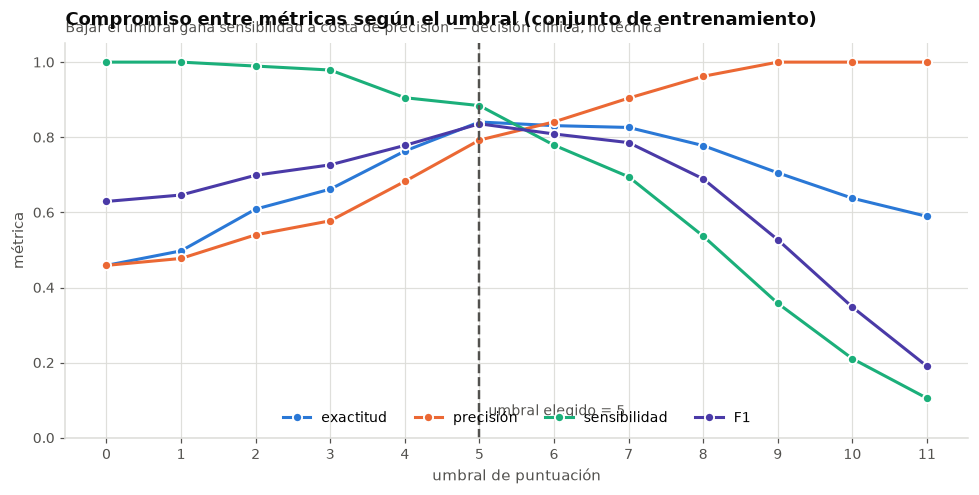

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.6))
for c, col in zip(
    ["exactitud", "precisión", "sensibilidad", "F1"], [PAL[0], PAL[1], PAL[2], PAL[6]]
):
    ax.plot(
        barrido["umbral"],
        barrido[c],
        marker="o",
        color=col,
        label=c,
        markeredgecolor="white",
        markeredgewidth=1.2,
        markersize=6,
    )
ax.axvline(UMBRAL, color=TXT2, ls="--", lw=1.6)
ax.text(UMBRAL + 0.12, 0.06, f"umbral elegido = {UMBRAL}", fontsize=9, color=TXT2)
ax.set_xticks(range(0, 12))
ax.set_xlabel("umbral de puntuación")
ax.set_ylabel("métrica")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9, ncol=4, loc="lower center")
titulo(
    ax,
    "Compromiso entre métricas según el umbral (conjunto de entrenamiento)",
    "Bajar el umbral gana sensibilidad a costa de precisión — decisión clínica, no técnica",
)
plt.tight_layout()
plt.show()

In [ ]:
pred_te = (s_te >= UMBRAL).astype(int)

met = {
    "Exactitud (accuracy)": accuracy_score(y_te, pred_te),
    "Precisión (precision)": precision_score(y_te, pred_te),
    "Sensibilidad (recall)": recall_score(y_te, pred_te),
    "F1": f1_score(y_te, pred_te),
    "AUC (sobre la puntuación)": roc_auc_score(y_te, s_te),
}
print("=== RESULTADOS EN EL CONJUNTO DE PRUEBA (nunca visto) ===")
for k, v in met.items():
    print(f"  {k:30s} {v:.3f}")
print(
    "\n",
    classification_report(
        y_te, pred_te, target_names=["Sin enfermedad", "Con enfermedad"], digits=3
    ),
)

=== RESULTADOS EN EL CONJUNTO DE PRUEBA (nunca visto) ===
  Exactitud (accuracy)           0.889
  Precisión (precision)          0.881
  Sensibilidad (recall)          0.881
  F1                             0.881
  AUC (sobre la puntuación)      0.946

                 precision    recall  f1-score   support

Sin enfermedad      0.896     0.896     0.896        48
Con enfermedad      0.881     0.881     0.881        42

      accuracy                          0.889        90
     macro avg      0.888     0.888     0.888        90
  weighted avg      0.889     0.889     0.889        90



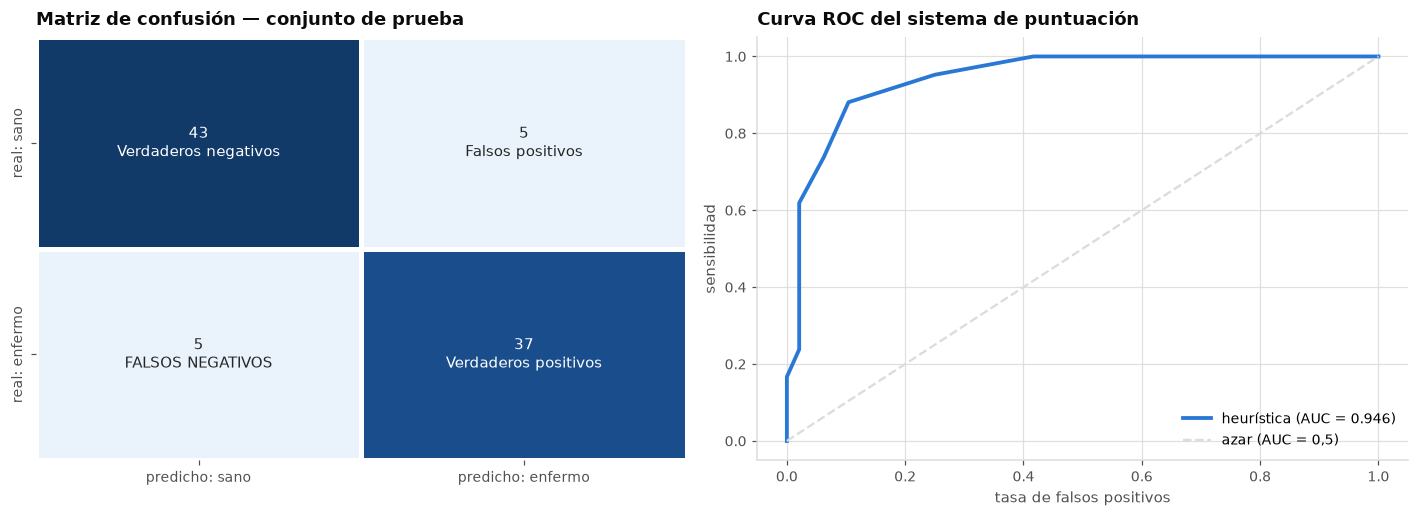

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

cm = confusion_matrix(y_te, pred_te)
etiquetas = np.array(
    [
        [f"{v}\n{n}" for v, n in zip(fila, nom)]
        for fila, nom in zip(
            cm,
            [
                ["Verdaderos negativos", "Falsos positivos"],
                ["FALSOS NEGATIVOS", "Verdaderos positivos"],
            ],
        )
    ]
)
sns.heatmap(
    cm,
    annot=etiquetas,
    fmt="",
    cmap=SEQ,
    linewidths=2,
    linecolor="white",
    ax=axes[0],
    cbar=False,
    annot_kws={"size": 10},
    xticklabels=["predicho: sano", "predicho: enfermo"],
    yticklabels=["real: sano", "real: enfermo"],
)
axes[0].grid(False)
titulo(axes[0], "Matriz de confusión — conjunto de prueba")

fpr, tpr, _ = roc_curve(y_te, s_te)
axes[1].plot(
    fpr,
    tpr,
    color=PAL[0],
    lw=2.5,
    label=f"heurística (AUC = {met['AUC (sobre la puntuación)']:.3f})",
)
axes[1].plot([0, 1], [0, 1], color=GRID, ls="--", lw=1.5, label="azar (AUC = 0,5)")
axes[1].set_xlabel("tasa de falsos positivos")
axes[1].set_ylabel("sensibilidad")
axes[1].legend(fontsize=9, loc="lower right")
titulo(axes[1], "Curva ROC del sistema de puntuación")
plt.tight_layout()
plt.show()

### 7.3 Comparación con líneas base

La heurística solo es interesante si supera al clasificador trivial y se acerca a modelos
de aprendizaje automático. Todos se evalúan con **validación cruzada estratificada de 5
particiones** sobre los mismos datos.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline

Xml = pd.get_dummies(df.drop(columns=[TGT]), drop_first=True).astype(float)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos = {
    "Clasificador trivial (clase mayoritaria)": DummyClassifier(
        strategy="most_frequent"
    ),
    "Árbol de decisión (profundidad 3)": DecisionTreeClassifier(
        max_depth=3, random_state=42
    ),
    "Random Forest (300 árboles)": RandomForestClassifier(
        n_estimators=300, random_state=42
    ),
    "Regresión logística": make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=2000)
    ),
}

filas = []
for nombre, m in modelos.items():
    acc = cross_val_score(m, Xml, y, cv=cv, scoring="accuracy")
    auc = cross_val_score(m, Xml, y, cv=cv, scoring="roc_auc")
    filas.append((nombre, acc.mean(), acc.std(), auc.mean()))

# La heuristica no se entrena: se evalua con el mismo esquema de particiones
acc_h, auc_h = [], []
for i_tr, i_te in cv.split(d, y):
    st, se = d["puntuacion"].iloc[i_tr], d["puntuacion"].iloc[i_te]
    yt, ye = y.iloc[i_tr], y.iloc[i_te]
    u = max(range(12), key=lambda t: accuracy_score(yt, (st >= t).astype(int)))
    acc_h.append(accuracy_score(ye, (se >= u).astype(int)))
    auc_h.append(roc_auc_score(ye, se))
filas.append(
    ("MODELO HEURÍSTICO (manual)", np.mean(acc_h), np.std(acc_h), np.mean(auc_h))
)

comp = pd.DataFrame(
    filas, columns=["modelo", "exactitud media (VC-5)", "desv. típica", "AUC media"]
)
comp = comp.sort_values("exactitud media (VC-5)", ascending=False).reset_index(
    drop=True
)
comp.round(4)

,modelo,exactitud media (VC-5),desv. típica,AUC media
0,MODELO HEURÍSTICO (manual),0.855,0.060,0.920
1,Regresión logística,0.818,0.050,0.895
2,Random Forest (300 árboles),0.791,0.055,0.895
3,Árbol de decisión (profundidad 3),0.784,0.027,0.829
4,Clasificador trivial (clase mayoritaria),0.539,0.004,0.500


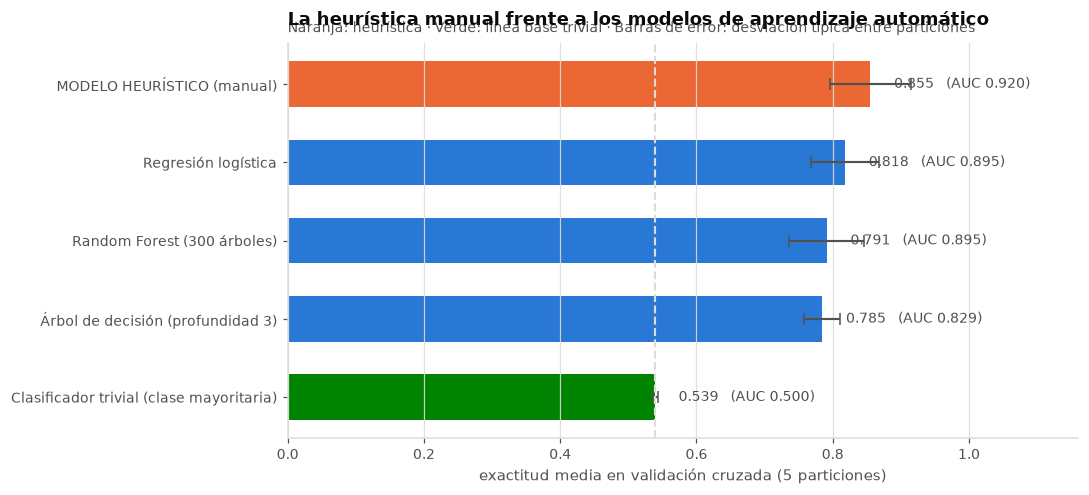

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4.6))
cc = comp.sort_values("exactitud media (VC-5)")
colores = [
    PAL[1] if "HEUR" in m else PAL[5] if "trivial" in m else PAL[0]
    for m in cc["modelo"]
]
b = ax.barh(
    cc["modelo"],
    cc["exactitud media (VC-5)"],
    color=colores,
    height=0.58,
    xerr=cc["desv. típica"],
    error_kw=dict(ecolor=TXT2, lw=1.4, capsize=4),
)
for rect, v, a in zip(b, cc["exactitud media (VC-5)"], cc["AUC media"]):
    ax.text(
        v + 0.035,
        rect.get_y() + rect.get_height() / 2,
        f"{v:.3f}   (AUC {a:.3f})",
        va="center",
        fontsize=9,
        color=TXT2,
    )
ax.axvline(y.value_counts(normalize=True).max(), color=GRID, ls="--", lw=1.4)
ax.set_xlim(0, 1.16)
ax.set_xlabel("exactitud media en validación cruzada (5 particiones)")
ax.grid(axis="y", visible=False)
titulo(
    ax,
    "La heurística manual frente a los modelos de aprendizaje automático",
    "Naranja: heurística · Verde: línea base trivial · Barras de error: desviación típica entre particiones",
)
plt.tight_layout()
plt.show()

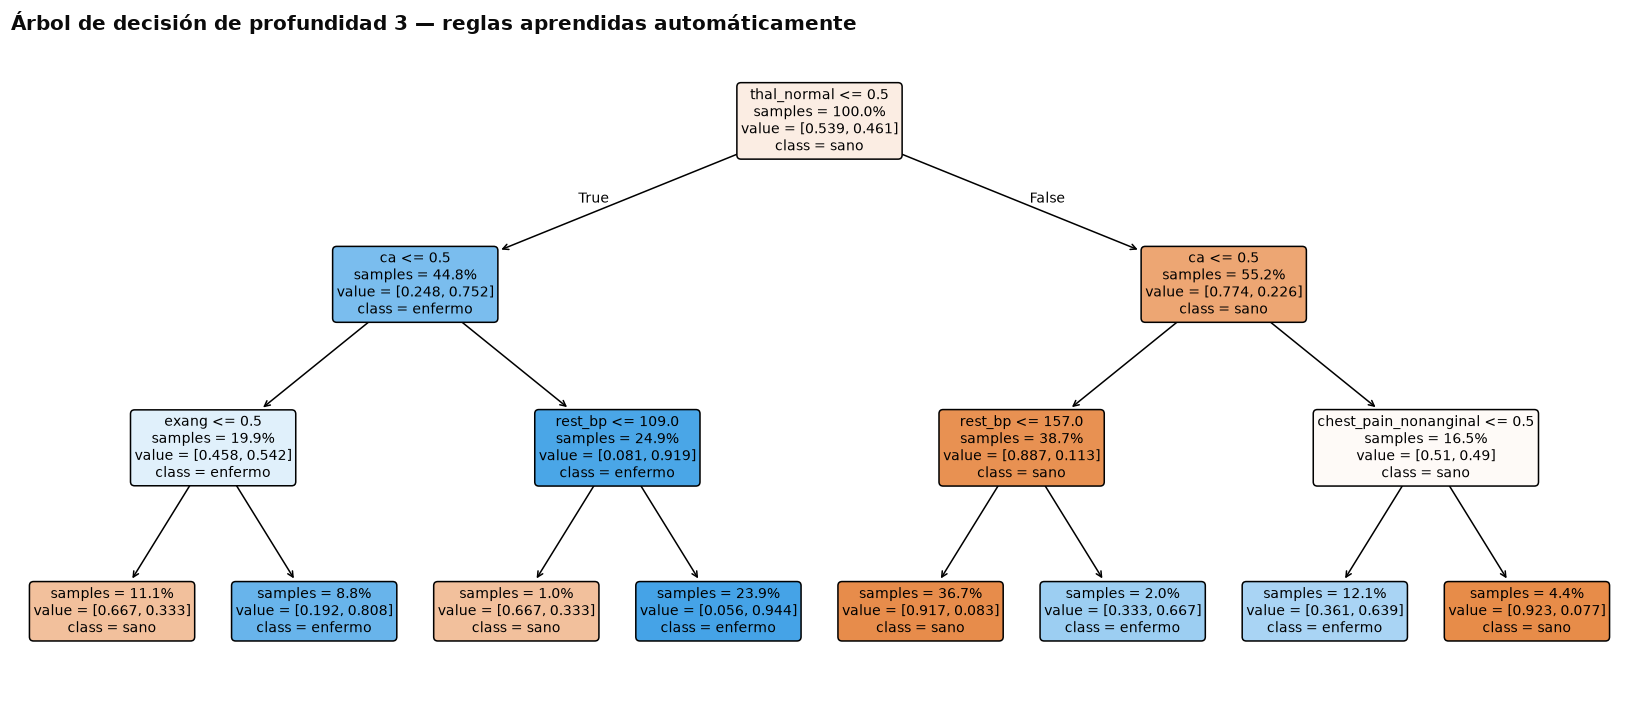

Comparación cualitativa: el árbol selecciona por su cuenta thal, ca, exang y
chest_pain — exactamente los cuatro atributos de mayor peso en la heurística manual.


In [ ]:
# El arbol de decision poco profundo produce reglas legibles: son "la heuristica que aprende la maquina"
arb = DecisionTreeClassifier(max_depth=3, random_state=42).fit(Xml, y)
fig, ax = plt.subplots(figsize=(15, 6.5))
plot_tree(
    arb,
    feature_names=list(Xml.columns),
    class_names=["sano", "enfermo"],
    filled=True,
    rounded=True,
    fontsize=9,
    impurity=False,
    ax=ax,
    proportion=True,
)
ax.set_title(
    "Árbol de decisión de profundidad 3 — reglas aprendidas automáticamente",
    loc="left",
    fontsize=13,
    fontweight="bold",
    color=TXT,
)
plt.tight_layout()
plt.show()

print("Comparación cualitativa: el árbol selecciona por su cuenta thal, ca, exang y")
print(
    "chest_pain — exactamente los cuatro atributos de mayor peso en la heurística manual."
)

---
## 8. Conclusiones

### 8.1 Sobre la estructura multivariable

1. **No hay redundancia aprovechable.** El PCA necesita ~8 de 13 componentes para el 80%
   de la varianza y el VIF no señala colinealidad severa (salvo la artificial que
   introduce `reserva_fc` por construcción). **Reducir dimensionalidad no compensa**: se
   perdería la interpretabilidad, que en diagnóstico médico es un requisito y no un lujo.

2. **Existe un eje dominante de "gravedad cardíaca"** (PC1), que combina `old_peak`, `ca`,
   `exang`, `slope`, `thal` y —con signo opuesto— `max_hr`. Es el bloque isquémico-anatómico
   ya identificado en el Notebook 2, ahora confirmado como la principal fuente de variación
   del conjunto.

3. **Los pacientes no forman grupos discretos, forman un continuo.** La silueta de K-Means
   es baja (~0,16), pero los dos grupos que encuentra separan un 77% de enfermos frente a
   un 16% **sin haber visto el diagnóstico** (Rand ajustado = 0,37). La estructura
   dominante y no supervisada de los datos *es* la enfermedad.

4. **Los efectos se suman, no interactúan.** La tasa de enfermedad crece de forma casi
   monótona con el número de factores de riesgo (~7% → ~100%), sin inversiones de signo.
   Esta es la condición precisa bajo la cual un modelo aditivo simple funciona bien.

### 8.2 Respuesta a la pregunta del enunciado: ¿es viable un modelo heurístico?

> ## Sí, es claramente viable.

Un sistema de puntuación de **ocho reglas con pesos de 1 y 2**, derivado del análisis y del
conocimiento clínico —sin ningún ajuste por optimización— alcanza en el conjunto de prueba
una **exactitud del 88,9%** y un **AUC de 0,946**. En validación cruzada de 5 particiones
obtiene **85,5% de exactitud y 0,920 de AUC**, por encima de la regresión logística (81,8%),
del Random Forest (79,1%) y del árbol de decisión (78,4%), y muy por encima del 53,9% del
clasificador trivial.

Conviene ser preciso sobre por qué la heurística gana: no es que sea "mejor algoritmo",
sino que sus reglas incorporan **conocimiento clínico externo** que los modelos tendrían
que aprender desde solo 297 ejemplos. Con esa cantidad de datos, ese conocimiento previo
vale más que la capacidad de ajuste. (El único parámetro que la heurística sí ajusta a los
datos es el umbral, y se ha elegido dentro de cada partición de entrenamiento, nunca
mirando la de prueba.)

Que el árbol de decisión de profundidad 3, entrenado de forma independiente, seleccione por
su cuenta `thal`, `ca`, `exang` y `chest_pain` —los cuatro atributos de mayor peso de la
heurística manual— es la mejor confirmación de que las reglas capturan la señal real y no
un artefacto del ajuste.

**Por qué funciona tan bien:**
- Los efectos son aditivos y monótonos (sección 6), justo lo que un sistema de puntuación modela.
- Los atributos predictores son marcadores clínicos ya validados: gran parte del trabajo de
  ingeniería de atributos venía hecho en el diseño del estudio.
- El problema tiene un techo de rendimiento natural (~85-90%) por el solapamiento entre
  clases que muestran el PCA y la matriz de dispersión. Los modelos complejos no pueden
  despegarse mucho de la heurística porque **la información sencillamente no está en los datos**.

**Cuándo conviene la heurística frente a un modelo entrenado:**

| A favor de la heurística | A favor del modelo entrenado |
|---|---|
| Totalmente transparente y auditable | Puede ajustar los pesos a los datos |
| Aplicable sin computador, junto a la cama del paciente | Calibra probabilidades, no solo la clase |
| No se degrada con el cambio de distribución | Aprovecha interacciones si aparecen más datos |
| El umbral se ajusta a la política clínica (priorizar sensibilidad) | Escala a muchos más atributos |

### 8.3 Recomendación final para el proyecto

1. **Adoptar la heurística como línea base oficial.** Cualquier modelo posterior debe
   superar su ~85% en validación cruzada para justificar su complejidad añadida.
2. **Bajar el umbral de 5 a 4 puntos en un uso clínico real.** El barrido de la sección 7.2
   muestra que se gana sensibilidad a costa de precisión, y en cribado un falso negativo
   (enviar a casa a un paciente enfermo) es mucho más costoso que un falso positivo
   (una prueba adicional). Es una decisión clínica, no estadística.
3. **Descartar `fbs`, transformar `chol` y fusionar `rest_ecg`** antes de cualquier modelado.
4. **Deduplicar siempre antes de particionar.** Es la advertencia más importante de todo el
   análisis: sobre el archivo crudo, las 3.030 filas replicadas producirían métricas de
   validación falsamente cercanas al 100%.
5. **Recoger los datos adicionales listados en el Notebook 1** (fracciones HDL/LDL,
   tabaquismo, diabetes, IMC, medicación). Dado que el rendimiento parece topado por la
   información disponible y no por el algoritmo, **más atributos rendirán mucho más que
   modelos más sofisticados**.